# 05 · Explicabilidade do modelo final
Carregamos o pipeline escolhido em CV no notebook 04. SHAP é calculado somente sobre esse modelo, sem novo ajuste e sem reamostragem do teste.

Usamos `PermutationExplainer` sobre o pipeline completo, permitindo explicar qualquer um dos quatro algoritmos nas unidades originais dos atributos preparados. Background: 50 registros aleatórios do treino original. Explicações: amostra aleatória de até 80 registros do teste, semente 42; 10 ciclos de permutação por observação. A importância global é a média de |SHAP| nessa amostra, não no dataset inteiro.

Para SVM, a unidade é margem de decisão; para os demais, saída `predict_proba` da classe 1, não calibrada. Contribuições positivas elevam essa saída em relação ao background. Dependência entre atributos e combinações artificiais no mascaramento limitam a interpretação: SHAP explica o modelo, não causas do churn. O caso local mostrado é o de maior score entre os registros amostrados, escolhido somente para ilustração.

In [1]:
from pathlib import Path
import sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/common.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.common import *
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.spines.top': False, 'axes.spines.right': False})
df, X, y, groups, tr, te = load_data()
X_train, X_test = X.iloc[tr], X.iloc[te]
y_train, y_test = y.iloc[tr], y.iloc[te]
for directory in ['reports/figuras', 'reports/tabelas', 'reports/dashboards', 'models']:
    (ROOT / directory).mkdir(parents=True, exist_ok=True)


In [2]:
import joblib, shap
model = joblib.load(ROOT/'models/modelo_final.joblib')
metadata = json.loads((ROOT/'reports/tabelas/model_metadata.json').read_text())
assert metadata['sha256'] == fingerprint()
background = X_train.sample(n=min(50,len(X_train)),random_state=SEED)
explain_data = X_test.sample(n=min(80,len(X_test)),random_state=SEED)
unit = 'Margem de decisão' if hasattr(model,'decision_function') else 'Score de probabilidade não calibrada'
def predict_output(values):
    data = pd.DataFrame(values,columns=X.columns)
    return model.decision_function(data) if hasattr(model,'decision_function') else model.predict_proba(data)[:,1]
explainer = shap.PermutationExplainer(predict_output, background, feature_names=list(X.columns), seed=SEED)
explanation = explainer(explain_data, max_evals=10*(2*X.shape[1]+1))
residual = np.max(np.abs(explanation.base_values + explanation.values.sum(axis=1) - predict_output(explain_data)))
assert residual < 1e-5, f'Falha na aditividade: {residual}'
importance = pd.DataFrame({'variavel':X.columns,'shap_absoluto_medio':np.abs(explanation.values).mean(axis=0)}).sort_values('shap_absoluto_medio',ascending=False)
importance.to_csv(ROOT/'reports/tabelas/shap_importancia.csv',index=False)
pd.DataFrame(explanation.values,index=explain_data.index,columns=X.columns).rename_axis('row_id').to_csv(ROOT/'reports/tabelas/shap_valores.csv')
explain_data.rename_axis('row_id').to_csv(ROOT/'reports/tabelas/shap_amostra.csv')
local = int(np.argmax(predict_output(explain_data)))
(ROOT/'reports/tabelas/shap_metadata.json').write_text(json.dumps({'modelo':metadata['vencedor'],'unidade':unit,'n_background':len(background),'n_explicados':len(explain_data),'max_erro_aditividade':float(residual),'row_id_local':int(explain_data.index[local]),'base_local':float(explanation.base_values[local]),'score_local':float(predict_output(explain_data)[local])},indent=2,ensure_ascii=False))
display(importance)
print('Unidade:',unit,'| Erro máximo de aditividade:',residual)

Unidade: Score de probabilidade não calibrada | Erro máximo de aditividade: 7.771561172376096e-16


PermutationExplainer explainer: 81it [00:17,  2.77it/s]


,variavel,shap_absoluto_medio
9,status,0.105416
1,complains,0.062934
5,frequency_of_use,0.047389
4,seconds_of_use,0.032940
2,subscription_length,0.032501
0,call_failure,0.023043
11,customer_value,0.019390
7,distinct_called_numbers,0.014764
6,frequency_of_sms,0.014358
10,age,0.011180


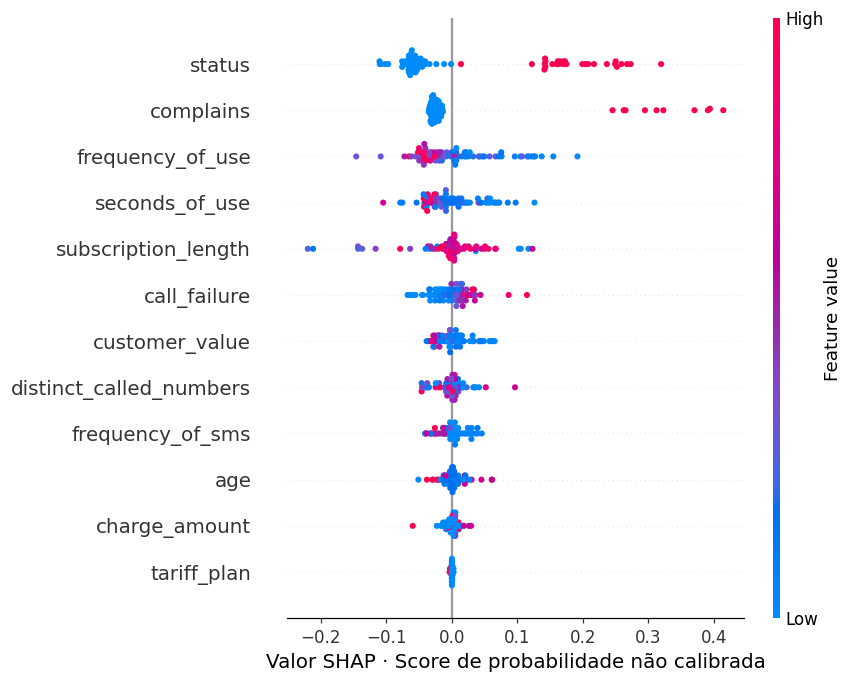

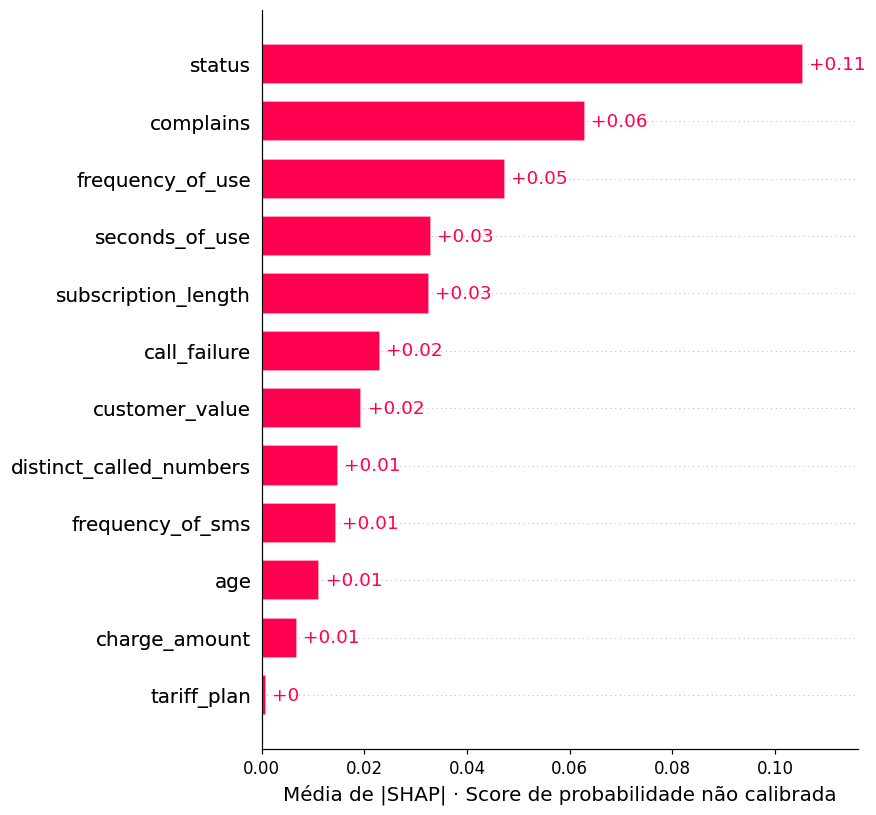

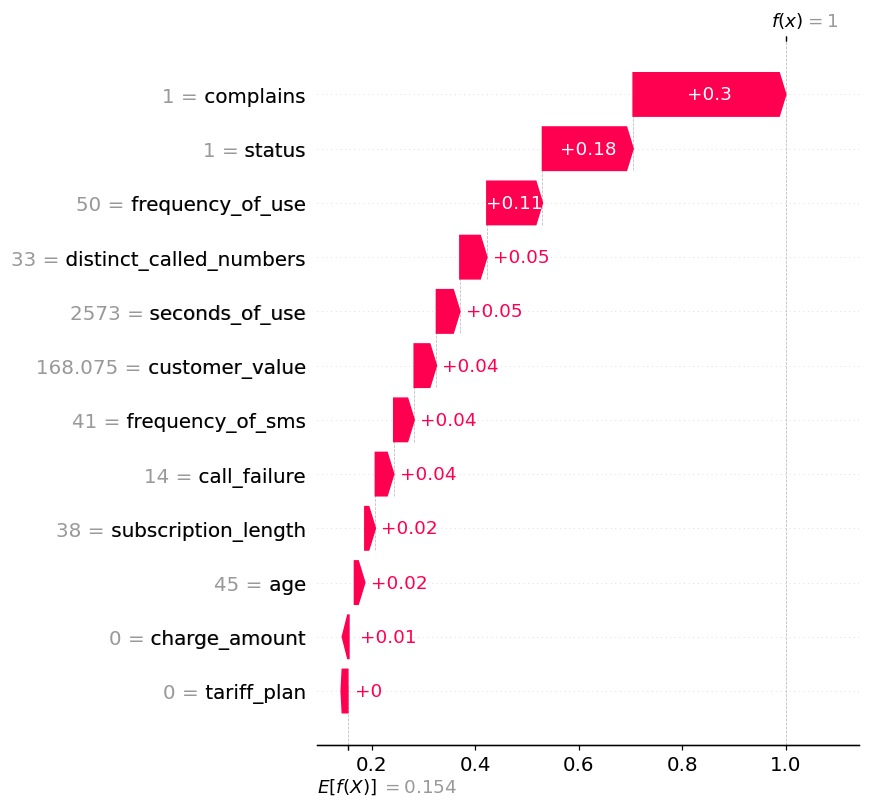

In [3]:
shap.plots.beeswarm(explanation, max_display=12, show=False)
plt.gca().set_xlabel('Valor SHAP · '+unit)
savefig(plt.gcf(),'shap_beeswarm')
plt.show()
shap.plots.bar(explanation,max_display=12,show=False)
plt.gca().set_xlabel('Média de |SHAP| · '+unit)
savefig(plt.gcf(),'shap_importancia')
plt.show()
shap.plots.waterfall(explanation[local],max_display=12,show=False)
savefig(plt.gcf(),'shap_local')
plt.show()